# Regression with an Abalone Dataset - Abalon Veri Kümesiyle Regresyon Analizi

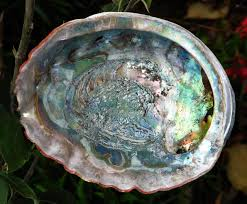

Bu projede, abalone canlılarının fiziksel özellikleri kullanılarak yaşlarının tahmin edilmesi amaçlanmıştır. Veri seti üzerinde çeşitli makine öğrenmesi regresyon modelleri uygulanmış ve elde edilen sonuçlar karşılaştırılarak en başarılı model belirlenmeye çalışılmıştır.


### Sütun Açıklamaları

**id** : Her satıra ait benzersiz kayıt numarasıdır. Model eğitiminde kullanılmaz.

**Sex** : Abalone'un cinsiyet bilgisidir. M = Erkek, F = Dişi, I = Yavru.

**Length** : Abalone kabuğunun en uzun noktadan ölçülen uzunluğudur.

**Diameter** : Uzunluğa dik yöndeki çap ölçüsüdür.

**Height** : Abalone'un yüksekliğini ifade eder.

**Whole weight** : Kabuk dahil tüm abalone'un toplam ağırlığıdır.

**Whole weight.1** : Kabuktan ayrılmış et kısmının ağırlığıdır (Shucked Weight).

**Whole weight.2** : İç organların ağırlığıdır (Viscera Weight).

**Shell weight** : Kurutulmuş kabuğun ağırlığıdır.

**Rings** : Kabuktaki halka sayısını gösterir. Veri setinin hedef değişkenidir ve abalone'un yaşını tahmin etmek için kullanılır.

### Veriseti Linki

https://www.kaggle.com/competitions/playground-series-s4e4/data

In [13]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/playground-series-s4e4/sample_submission.csv
/kaggle/input/competitions/playground-series-s4e4/train.csv
/kaggle/input/competitions/playground-series-s4e4/test.csv


In [14]:
# Veri işleme
import pandas as pd
import numpy as np

# Görselleştirme
import matplotlib.pyplot as plt
import seaborn as sns

# Veri ön işleme
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Regresyon Modelleri
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor
)
from sklearn.neighbors import KNeighborsRegressor

# Performans Metrikleri
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    mean_squared_log_error
)

# Uyarıları kapat
import warnings
warnings.filterwarnings("ignore")

In [15]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    print(dirname)

/kaggle/input
/kaggle/input/competitions
/kaggle/input/competitions/playground-series-s4e4


In [16]:
train = pd.read_csv("/kaggle/input/competitions/playground-series-s4e4/train.csv")
test = pd.read_csv("/kaggle/input/competitions/playground-series-s4e4/test.csv")
sample = pd.read_csv("/kaggle/input/competitions/playground-series-s4e4/sample_submission.csv")

In [17]:
train.head()

,id,Sex,Length,Diameter,Height,Whole weight,Whole weight.1,Whole weight.2,Shell weight,Rings
0,0,F,0.550,0.430,0.150,0.7715,0.3285,0.1465,0.2400,11
1,1,F,0.630,0.490,0.145,1.1300,0.4580,0.2765,0.3200,11
2,2,I,0.160,0.110,0.025,0.0210,0.0055,0.0030,0.0050,6
3,3,M,0.595,0.475,0.150,0.9145,0.3755,0.2055,0.2500,10
4,4,I,0.555,0.425,0.130,0.7820,0.3695,0.1600,0.1975,9


In [22]:
train.isnull().sum()

id                0
Length            0
Diameter          0
Height            0
Whole weight      0
Whole weight.1    0
Whole weight.2    0
Shell weight      0
Rings             0
Sex_I             0
Sex_M             0
dtype: int64

In [18]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90615 entries, 0 to 90614
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              90615 non-null  int64  
 1   Sex             90615 non-null  object 
 2   Length          90615 non-null  float64
 3   Diameter        90615 non-null  float64
 4   Height          90615 non-null  float64
 5   Whole weight    90615 non-null  float64
 6   Whole weight.1  90615 non-null  float64
 7   Whole weight.2  90615 non-null  float64
 8   Shell weight    90615 non-null  float64
 9   Rings           90615 non-null  int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 6.9+ MB


In [19]:
train = pd.get_dummies(train, columns=["Sex"], drop_first=True)

In [20]:
test = pd.get_dummies(test, columns=["Sex"], drop_first=True)

In [21]:
train.shape

(90615, 11)

In [23]:
train.describe()

,id,Length,Diameter,Height,Whole weight,Whole weight.1,Whole weight.2,Shell weight,Rings
count,90615.000000,90615.000000,90615.000000,90615.000000,90615.000000,90615.000000,90615.000000,90615.000000,90615.000000
mean,45307.000000,0.517098,0.401679,0.135464,0.789035,0.340778,0.169422,0.225898,9.696794
std,26158.441658,0.118217,0.098026,0.038008,0.457671,0.204428,0.100909,0.130203,3.176221
min,0.000000,0.075000,0.055000,0.000000,0.002000,0.001000,0.000500,0.001500,1.000000
25%,22653.500000,0.445000,0.345000,0.110000,0.419000,0.177500,0.086500,0.120000,8.000000
50%,45307.000000,0.545000,0.425000,0.140000,0.799500,0.330000,0.166000,0.225000,9.000000
75%,67960.500000,0.600000,0.470000,0.160000,1.067500,0.463000,0.232500,0.305000,11.000000
max,90614.000000,0.815000,0.650000,1.130000,2.825500,1.488000,0.760000,1.005000,29.000000


In [24]:
train["Rings"].describe()

count    90615.000000
mean         9.696794
std          3.176221
min          1.000000
25%          8.000000
50%          9.000000
75%         11.000000
max         29.000000
Name: Rings, dtype: float64

In [25]:
train = train.drop("id", axis=1)
test = test.drop("id", axis=1)

In [26]:
train.head()

,Length,Diameter,Height,Whole weight,Whole weight.1,Whole weight.2,Shell weight,Rings,Sex_I,Sex_M
0,0.550,0.430,0.150,0.7715,0.3285,0.1465,0.2400,11,False,False
1,0.630,0.490,0.145,1.1300,0.4580,0.2765,0.3200,11,False,False
2,0.160,0.110,0.025,0.0210,0.0055,0.0030,0.0050,6,True,False
3,0.595,0.475,0.150,0.9145,0.3755,0.2055,0.2500,10,False,True
4,0.555,0.425,0.130,0.7820,0.3695,0.1600,0.1975,9,True,False


In [27]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90615 entries, 0 to 90614
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Length          90615 non-null  float64
 1   Diameter        90615 non-null  float64
 2   Height          90615 non-null  float64
 3   Whole weight    90615 non-null  float64
 4   Whole weight.1  90615 non-null  float64
 5   Whole weight.2  90615 non-null  float64
 6   Shell weight    90615 non-null  float64
 7   Rings           90615 non-null  int64  
 8   Sex_I           90615 non-null  bool   
 9   Sex_M           90615 non-null  bool   
dtypes: bool(2), float64(7), int64(1)
memory usage: 5.7 MB


In [28]:
# Hedef değişken
y = train["Rings"]

# Bağımsız değişkenler
x = train.drop("Rings", axis=1)

In [29]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.20,
    random_state=42
)

In [30]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(72492, 9)
(18123, 9)
(72492,)
(18123,)


In [32]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(x_train, y_train)

tahmin_lr = model.predict(x_test)

r2_lr = r2_score(y_test, tahmin_lr)

r2_lr

0.6013258646157316

In [33]:
from sklearn.linear_model import Ridge

model = Ridge()

model.fit(x_train, y_train)

tahmin_ridge = model.predict(x_test)

r2_ridge = r2_score(y_test, tahmin_ridge)

r2_ridge

0.6010218710132151

In [35]:
from sklearn.linear_model import ElasticNet

model = ElasticNet()

model.fit(x_train, y_train)

tahmin_en = model.predict(x_test)

r2_en = r2_score(y_test, tahmin_en)

r2_en

0.12260729613864019

In [36]:
from sklearn.tree import DecisionTreeRegressor

model = DecisionTreeRegressor(random_state=42)

model.fit(x_train, y_train)

tahmin_dt = model.predict(x_test)

r2_dt = r2_score(y_test, tahmin_dt)

r2_dt

0.3173508404748009

In [37]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(random_state=42)

model.fit(x_train, y_train)

tahmin_rf = model.predict(x_test)

r2_rf = r2_score(y_test, tahmin_rf)

r2_rf

0.6478710418656821

In [38]:
from sklearn.ensemble import ExtraTreesRegressor

model = ExtraTreesRegressor(random_state=42)

model.fit(x_train, y_train)

tahmin_etr = model.predict(x_test)

r2_etr = r2_score(y_test, tahmin_etr)

r2_etr

0.6452358907378726

In [39]:
from sklearn.ensemble import GradientBoostingRegressor

model = GradientBoostingRegressor(random_state=42)

model.fit(x_train, y_train)

tahmin_gb = model.predict(x_test)

r2_gb = r2_score(y_test, tahmin_gb)

r2_gb

0.6414575111113295

In [40]:
from sklearn.neighbors import KNeighborsRegressor

model = KNeighborsRegressor()

model.fit(x_train, y_train)

tahmin_knn = model.predict(x_test)

r2_knn = r2_score(y_test, tahmin_knn)

r2_knn

0.6024397744940861

In [41]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import GradientBoostingRegressor, ExtraTreesRegressor, RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import pandas as pd
import numpy as np


def algo_test(x, y):

    # Modeller
    L    = LinearRegression()
    R    = Ridge()
    Lass = Lasso()
    E    = ElasticNet()
    RF   = RandomForestRegressor(random_state=42)
    ETR  = ExtraTreesRegressor(random_state=42)
    GBR  = GradientBoostingRegressor(random_state=42)
    KNN  = KNeighborsRegressor()
    DT   = DecisionTreeRegressor(random_state=42)

    algos = [L, R, Lass, E, RF, ETR, GBR, KNN, DT]

    algo_names = [
        "Linear Regression",
        "Ridge",
        "Lasso",
        "ElasticNet",
        "Random Forest",
        "Extra Trees",
        "Gradient Boosting",
        "KNeighborsRegressor",
        "Decision Tree"
    ]

    # Train-Test Split
    x_train, x_test, y_train, y_test = train_test_split(
        x, y,
        test_size=0.20,
        random_state=42
    )

    r_squared = []
    rmse = []
    mae = []

    # Model eğitimi ve değerlendirme
    for algo in algos:

        algo.fit(x_train, y_train)

        y_pred = algo.predict(x_test)

        r_squared.append(r2_score(y_test, y_pred))
        rmse.append(np.sqrt(mean_squared_error(y_test, y_pred)))
        mae.append(mean_absolute_error(y_test, y_pred))

    # Sonuç tablosu
    result = pd.DataFrame({
        "Model": algo_names,
        "R_Squared": r_squared,
        "RMSE": rmse,
        "MAE": mae
    })

    result = result.sort_values("R_Squared", ascending=False)

    return result

In [42]:
algo_test(x, y)

,Model,R_Squared,RMSE,MAE
4,Random Forest,6.478710e-01,1.901892,1.294399
5,Extra Trees,6.452359e-01,1.908995,1.301446
6,Gradient Boosting,6.414575e-01,1.919134,1.298759
7,KNeighborsRegressor,6.024398e-01,2.020861,1.364675
0,Linear Regression,6.013259e-01,2.023690,1.393015
1,Ridge,6.010219e-01,2.024462,1.393050
8,Decision Tree,3.173508e-01,2.648097,1.745186
3,ElasticNet,1.226073e-01,3.002148,2.152632
2,Lasso,-2.449884e-07,3.205052,2.349198


## Sonuç

Uygulanan regresyon modelleri karşılaştırıldığında en başarılı sonucun Random Forest Regressor modeli ile elde edildiği görülmüştür. Bu model 0.648 R² değeri, 1.91 RMSE ve 1.29 MAE sonuçları ile diğer modellere göre daha iyi performans göstermiştir. Random Forest modelini sırasıyla Extra Trees ve Gradient Boosting modelleri takip etmiştir. Elde edilen sonuçlar, abalone yaş tahmini probleminde ağaç tabanlı topluluk (ensemble) yöntemlerinin doğrusal regresyon modellerine göre daha başarılı olduğunu göstermektedir.